# 00 — SHAP exploration: what each FTTL version *looks at*

A **standalone microscope** on the three real-lineage FTTL models — **v1 → v2a → v3a** — before any
DiD estimator is layered on top. Three questions:

1. **Global** — which features drive each version, and how does the ranking move across versions?
2. **Dependency** — for the headline drivers, *how* does the model map a feature value to a
   log-odds contribution, and does that shape shift as the loop contaminates later versions?
3. **Cross-check** — does XGBoost's own `plot_importance` (split gain) tell the same story as SHAP?

### Which models does this notebook use — and why *not* the baseline `.pkl`s

There are two model representations in the repo. They are **not** interchangeable for SHAP:

| | `src/models/synthetic/baseline/v{1,2,3}.pkl` | **refit-from-spec (this notebook)** |
|---|---|---|
| what it is | `Pipeline(V{N}FeatureBuilder + XGB)` — each version's **own** preprocessing | plain `XGBClassifier` on **one shared** design matrix |
| feature space | **differs per version** (each builder selects/encodes its own set) | **identical** across v1/v2a/v3a — *required* for comparable SHAP |
| how to load | needs `fttl_vX` importable ⇒ **one version per venv** (`src/envs/vX`) | all three in a single kernel |
| reproduces logged score | yes | yes — checked below (fidelity table) |

Cross-version SHAP is only meaningful on a **common feature axis** — you cannot put v1 and v3a on the
same dependency plot if their columns differ. So this notebook uses the **same refit idiom as
`04_02_p7_SHAP_DiD`**: reuse the DGP's own `V1_SPEC / V2A_SPEC / V3A_SPEC`, hold the estimator and
hyper-parameters fixed, and vary **only** `(training window, label column)`. A fidelity check confirms
each refit reproduces the logged `model_{tag}_score`, so we are dissecting the *production* scorer, not
a lookalike. The baseline pkls remain the right tool for single-version production scoring (`predict.py`);
they are the wrong tool for a cross-version SHAP comparison.

> **Interventional + log-odds margin** SHAP throughout — matching 04_02, so numbers here and there are
> directly comparable. (The *why* is argued at length in 04_02; here we just adopt it.)

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# --- repo-root discovery (same idiom as the build notebooks) -----------------
ROOT = Path.cwd()
while not (ROOT / "src" / "data" / "synthetic" / "run.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))                          # -> config.py, figstyle.py
sys.path.insert(0, str(ROOT / "src" / "data" / "synthetic"))   # -> generate.* (the DGP package)

from config import DECISION_RULES, TARGET_PRECISION
SCRAP_THRESHOLD = DECISION_RULES['v2']['regimes'][0]['threshold']           # 0.872 · 0.985 — documented anchors
# reuse the generator's OWN specs + window logic, never re-typed (guarantees we refit the real scorer)
from generate.config import V1_SPEC, V2A_SPEC, V3A_SPEC, SEED, CATEGORICAL_COLS
from generate.model import _build_train_mask, _train_cutoff, _tune_threshold

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
import xgboost as xgb
import shap

import figstyle
figstyle.apply()                                               # house palette + fonts, call once

RNG = np.random.default_rng(SEED)
VERSIONS = ["v1", "v2a", "v3a"]
VCOLOR   = {"v1": figstyle.NEUTRAL, "v2a": figstyle.BLUE, "v3a": figstyle.RED}  # clean→near-clean→contaminated
print(f"shap {shap.__version__} · xgboost {xgb.__version__} · seed {SEED} · τ_anchor={SCRAP_THRESHOLD}")

shap 0.51.0 · xgboost 3.2.0 · seed 42 · τ_anchor=0.872


## 1 · Data — one shared design matrix

The synthetic feature parquets are **column-identical** across versions (asserted below), so a single
matrix `X` serves all three models. One-hot columns are noted against their parent categorical for
later grouping, but **dependency plots run on the raw numeric features** — that is where a
value→contribution *shape* is interpretable.

In [2]:
GEN = ROOT / "src" / "data" / "synthetic" / "generate"

claims = pd.read_parquet(GEN / "parquet" / "claims_all.parquet")
dates  = pd.to_datetime(claims["claim_date"])

feat = {v: pd.read_parquet(GEN / "parquet" / "features" / f"features_{v}.parquet") for v in VERSIONS}
cols_v1 = list(feat["v1"].columns)
for v, f in feat.items():
    assert list(f.columns) == cols_v1,           f"{v}: feature columns differ — SHAP not comparable"
    assert (f["claim_id"].values == claims["claim_id"].values).all(), f"{v}: row order differs"

X        = feat["v1"].drop(columns=["claim_id"]).astype(float)     # the one shared design matrix
FEATURES = list(X.columns)

# numeric (dependency-plot-able) vs one-hot (categorical) split
ONEHOT     = [c for c in FEATURES if any(c.startswith(k + "_") for k in CATEGORICAL_COLS)]
CONTINUOUS = [c for c in FEATURES if c not in ONEHOT]
print(f"rows {len(X):,} · features {len(FEATURES)} "
      f"({len(CONTINUOUS)} numeric, {len(ONEHOT)} one-hot) · feature space identical across v1/v2a/v3a ✓")
print("numeric features:", ", ".join(CONTINUOUS))

rows 70,000 · features 86 (14 numeric, 72 one-hot) · feature space identical across v1/v2a/v3a ✓
numeric features: vehicle_age_years, mileage, driver_age, prior_claims_count, customer_tenure_years, repair_to_value_ratio, vehicle_value, repair_estimate_gbp, report_delay_days, used_car_price_index, is_weekend_claim, has_prior_claims, is_high_value_vehicle, car_driveable


## 2 · Refit v1 / v2a / v3a and prove fidelity

Identical `XGBClassifier` + hyper-parameters for every version; only the DGP-defined `(window, label)`
changes. The **fidelity check** then confirms each refit's per-row scores track the logged production
`model_{tag}_score` — if it did not, every SHAP value below would describe the wrong function.

In [3]:
HPARAMS = dict(n_estimators=100, random_state=SEED, eval_metric="logloss")   # same as 04_02

def fit_version(spec) -> dict:
    "Refit one version exactly as the DGP did: same window, same label, same HPs."
    cutoff       = _train_cutoff(spec.cutoff_end_year)
    mask, y_all  = _build_train_mask(claims, dates, spec, cutoff)
    X_tr         = X.loc[mask]
    y_tr         = y_all.reindex(X_tr.index).astype(int)
    X_fit, X_val, y_fit, y_val = train_test_split(
        X_tr, y_tr, test_size=0.2, random_state=SEED, stratify=y_tr)
    model = XGBClassifier(**HPARAMS).fit(X_fit, y_fit)
    tau_v = _tune_threshold(y_val.to_numpy(), model.predict_proba(X_val)[:, 1])
    return dict(tag=spec.tag, model=model, tau=tau_v, n_train=int(mask.sum()),
                pos_rate=float(y_tr.mean()))

FITS = {s.tag: fit_version(s) for s in (V1_SPEC, V2A_SPEC, V3A_SPEC)}

# --- fidelity: do the refits reproduce the logged production scores? ----------
rows = []
for tag, f in FITS.items():
    refit  = f["model"].predict_proba(X)[:, 1]
    logged = claims[f"model_{tag}_score"].to_numpy()
    rows.append(dict(version=tag, n_train=f["n_train"], pos_rate=round(f["pos_rate"], 3),
                     tau_v=round(f["tau"], 4),
                     corr_vs_logged=round(np.corrcoef(refit, logged)[0, 1], 4),
                     max_abs_diff=round(float(np.abs(refit - logged).max()), 4)))
fidelity = pd.DataFrame(rows).set_index("version")
print(fidelity.to_string())
assert (fidelity["corr_vs_logged"] > 0.99).all(), "refit does not reproduce a logged score — stop"
print("\nfidelity ✓ — SHAP below dissects the production scorer, not a lookalike")

         n_train  pos_rate   tau_v  corr_vs_logged  max_abs_diff
version                                                         
v1         41457     0.146  0.9993             1.0        0.0001
v2a        17900     0.156  0.9761             1.0        0.0001
v3a        10191     0.164  0.9875             1.0        0.0001

fidelity ✓ — SHAP below dissects the production scorer, not a lookalike


## 3 · SHAP values — interventional, log-odds margin

`TreeExplainer` with a **fixed background sample** (interventional perturbation) and `model_output="raw"`
(the additive log-odds margin). Fixing one shared background means any difference between versions **is**
a difference in the model function, not in the reference distribution. We explain a common random sample
of rows so all three versions are measured on the *same* claims.

In [4]:
N_BG, N_EXPLAIN = 500, 3000                                   # background · rows to explain
bg_idx  = RNG.choice(len(X), size=N_BG,      replace=False)
exp_idx = RNG.choice(len(X), size=N_EXPLAIN, replace=False)
X_bg, X_exp = X.iloc[bg_idx], X.iloc[exp_idx].reset_index(drop=True)

SHAP = {}                                                        # tag -> shap_values ndarray (N_EXPLAIN × n_feat)
for tag in VERSIONS:
    expl = shap.TreeExplainer(FITS[tag]["model"], data=X_bg,
                              feature_perturbation="interventional", model_output="raw")
    SHAP[tag] = expl.shap_values(X_exp)
    print(f"{tag}: SHAP {SHAP[tag].shape}  ·  mean|φ| over all features = {np.abs(SHAP[tag]).mean():.4f}")

def mean_abs(tag) -> pd.Series:                                  # global importance = mean|SHAP| per feature
    return pd.Series(np.abs(SHAP[tag]).mean(0), index=FEATURES).sort_values(ascending=False)

MABS = {tag: mean_abs(tag) for tag in VERSIONS}

v1: SHAP (3000, 86)  ·  mean|φ| over all features = 0.0450


v2a: SHAP (3000, 86)  ·  mean|φ| over all features = 0.0523


v3a: SHAP (3000, 86)  ·  mean|φ| over all features = 0.0553


## 4 · Global importance — how the ranking moves v1 → v2a → v3a

Top features by mean|SHAP|, one bar group per version. Watch whether mass **concentrates** onto the
fast-track driver (`repair_to_value_ratio`) in the later, loop-exposed versions — that concentration is
the fingerprint 04_02 turns into a DiD estimate.

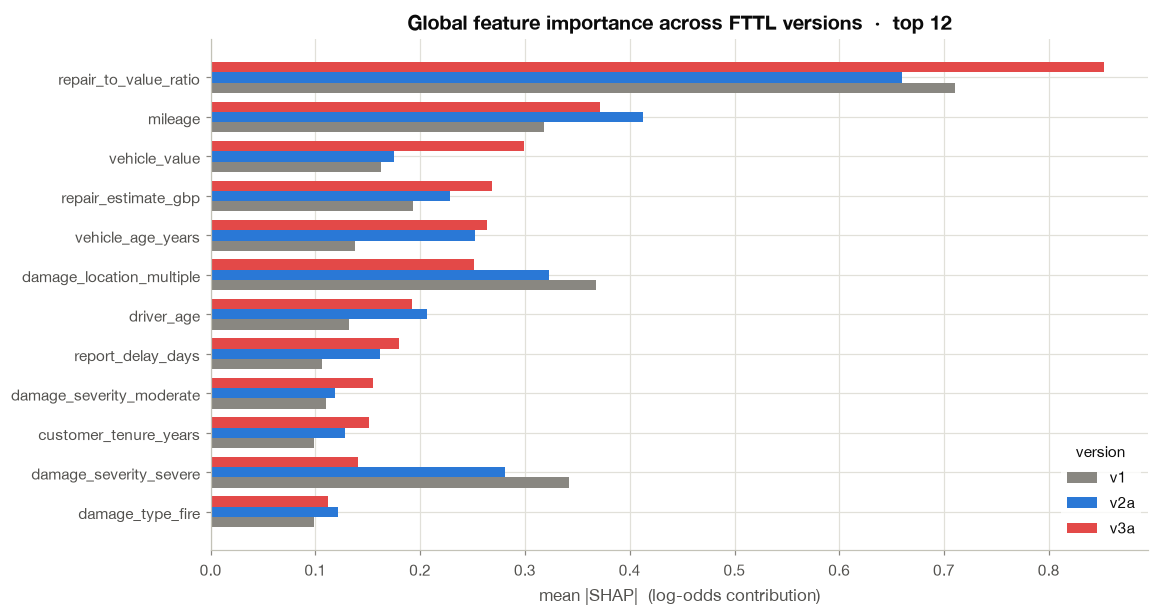

In [ ]:
TOPN = 12
order = MABS["v3a"].head(TOPN).index[::-1]                       # rank by the most-contaminated version
imp   = pd.DataFrame({tag: MABS[tag].reindex(order) for tag in VERSIONS})

fig, ax = plt.subplots(figsize=(figstyle.FIG_2[0], 0.42 * TOPN + 1))
y = np.arange(len(order)); h = 0.26
for i, tag in enumerate(VERSIONS):
    ax.barh(y + (i - 1) * h, imp[tag].values, height=h, color=VCOLOR[tag], label=tag)
ax.set_yticks(y); ax.set_yticklabels(order)
ax.set_xlabel("mean |SHAP|  (log-odds contribution)")
ax.set_title(f"Global feature importance across FTTL versions  ·  top {TOPN}")
ax.legend(title="version", loc="lower right")
figstyle.save(fig, "00_shap_global_importance"); plt.show()

## 5 · Cross-check — XGBoost `plot_importance` (split gain)

SHAP and XGBoost's built-in importance answer **different** questions. `plot_importance` with
`importance_type="gain"` reports the average training-loss reduction each feature's splits delivered —
a *structural* view of the fitted trees, blind to the background distribution and to feature
correlation. SHAP is an *attribution* over actual predictions. They usually agree on the headline
drivers; where they diverge is itself informative (gain over-credits high-cardinality split-happy
features). Shown per version for comparison.

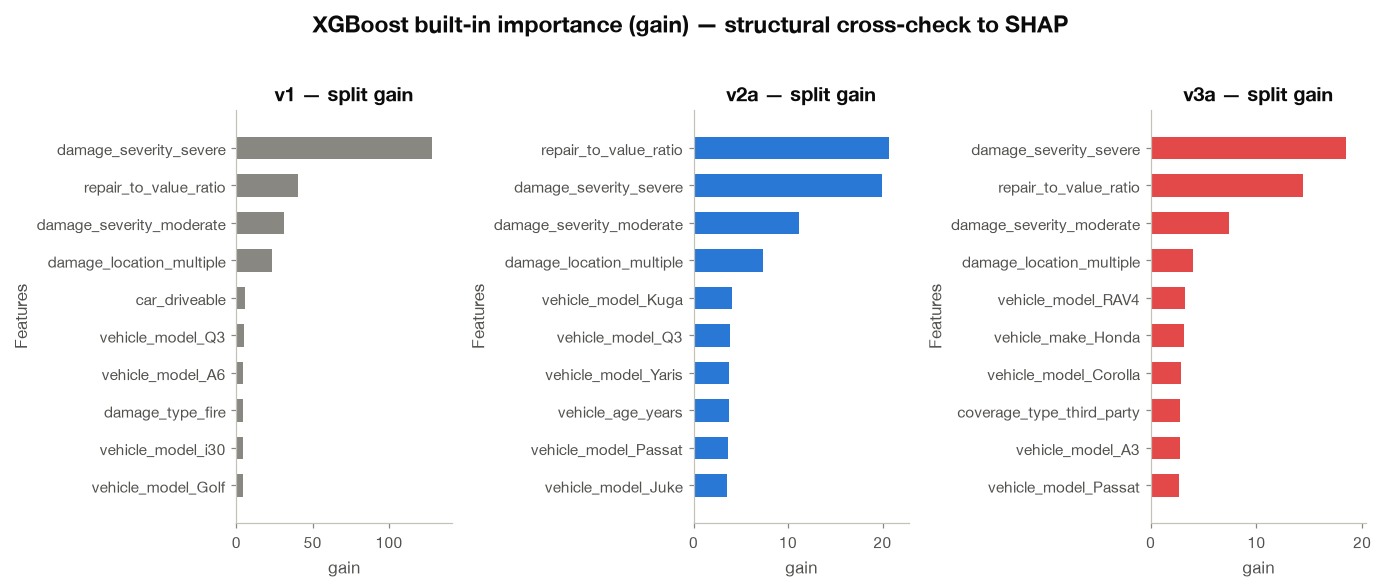

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(figstyle.FIG_2[0] * 1.15, 5.2))
for ax, tag in zip(axes, VERSIONS):
    xgb.plot_importance(FITS[tag]["model"], importance_type="gain", max_num_features=10,
                        ax=ax, height=0.6, color=VCOLOR[tag], grid=False,
                        show_values=False, title=f"{tag} — split gain")
    ax.set_xlabel("gain")
fig.suptitle("XGBoost built-in importance (gain) — structural cross-check to SHAP", y=1.02)
fig.tight_layout()
figstyle.save(fig, "00_xgb_plot_importance_gain"); plt.show()

## 6 · Dependency plots — the value → contribution *shape*

The core plot. For a feature, each point is one claim: x = its feature value, y = that feature's SHAP
contribution to the log-odds. The **shape** of the cloud is the model's learned response; SHAP colours
each point by the strongest interacting feature. Laid out **1×3 per feature (v1 | v2a | v3a) on shared
axes**, so a change in slope or a hardening step as versions progress is read straight off the row —
that is the corruption footprint made visible at the feature level.

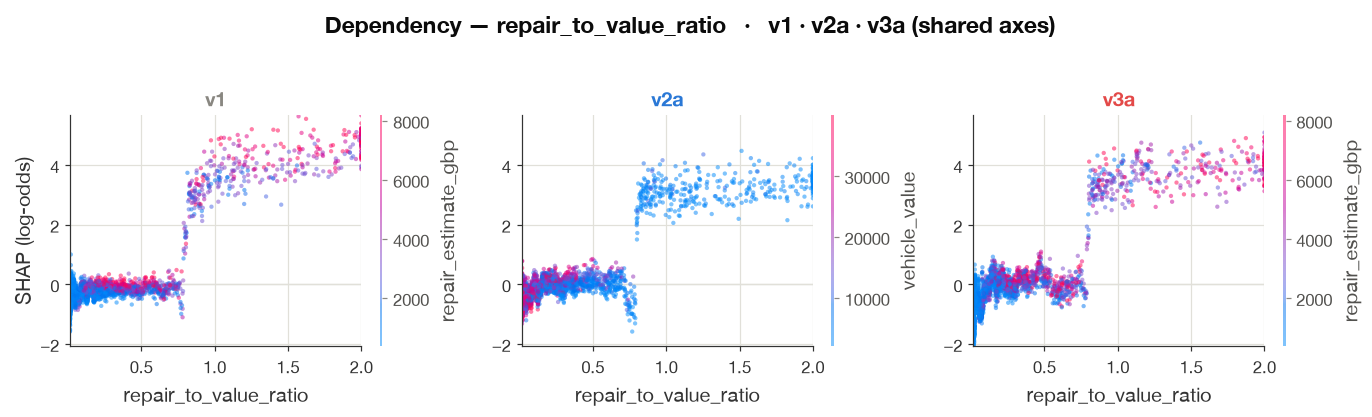

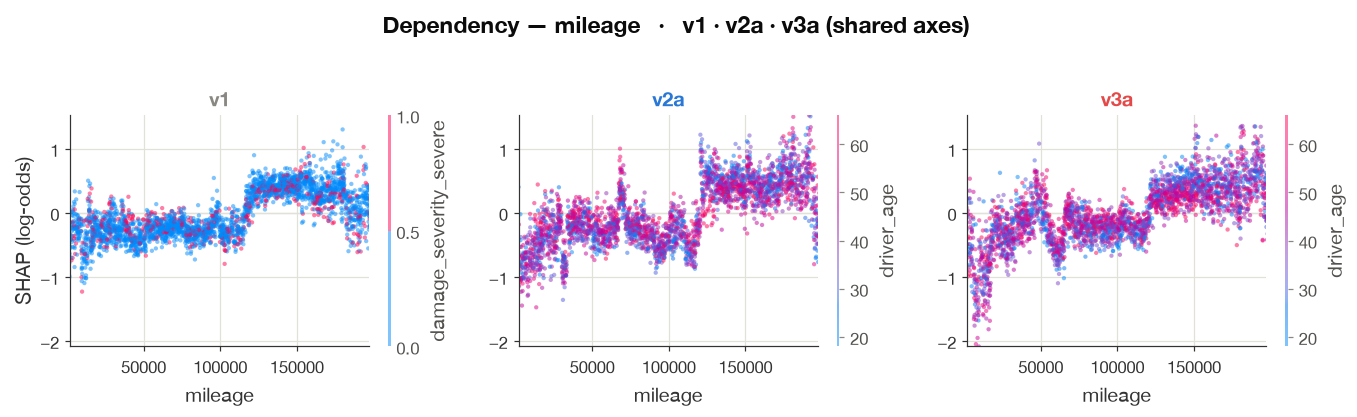

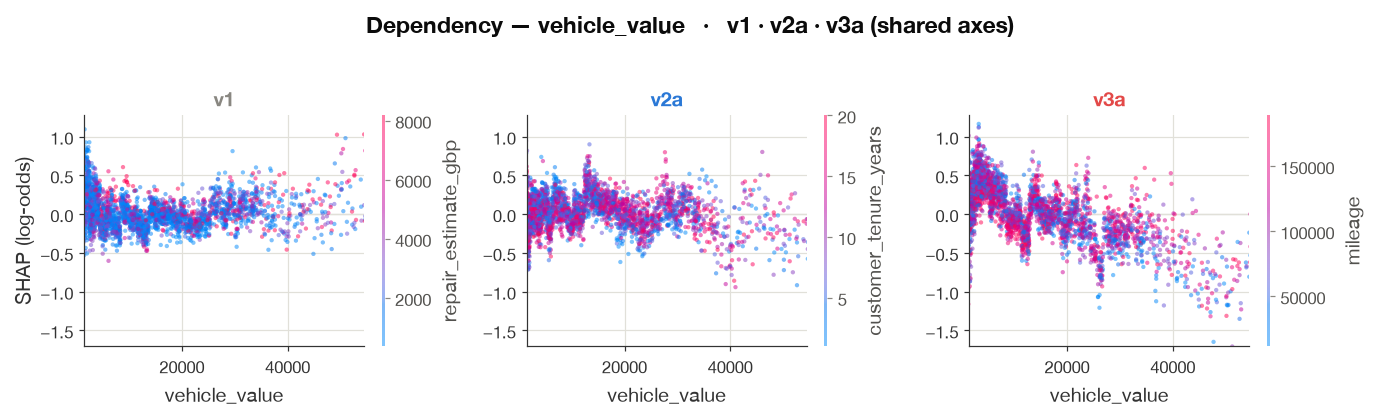

In [7]:
# headline driver first, then the next strongest numeric features by v3a importance
lead = "repair_to_value_ratio"
DEP_FEATURES = [lead] + [f for f in MABS["v3a"].index if f in CONTINUOUS and f != lead][:2]

for feat in DEP_FEATURES:
    j = FEATURES.index(feat)
    ymin = min(SHAP[t][:, j].min() for t in VERSIONS)
    ymax = max(SHAP[t][:, j].max() for t in VERSIONS)
    xv   = X_exp[feat].values
    xlo, xhi = np.percentile(xv, 1), np.percentile(xv, 99)      # trim display tails

    fig, axes = plt.subplots(1, 3, figsize=(figstyle.FIG_2[0] * 1.15, 3.6), sharex=True, sharey=True)
    for ax, tag in zip(axes, VERSIONS):
        shap.dependence_plot(feat, SHAP[tag], X_exp, interaction_index="auto",
                             ax=ax, show=False, dot_size=8, alpha=0.5)
        ax.set_title(f"{tag}", color=VCOLOR[tag], fontweight="bold")
        ax.set_xlim(xlo, xhi); ax.set_ylim(ymin, ymax)
        ax.axhline(0, color=figstyle.AXIS, lw=0.8, zorder=0)
        ax.set_ylabel("SHAP (log-odds)" if ax is axes[0] else "")
    fig.suptitle(f"Dependency — {feat}   ·   v1 · v2a · v3a (shared axes)", y=1.04)
    fig.tight_layout()
    figstyle.save(fig, f"00_shap_dependence_{feat}"); plt.show()

## Notes & next steps

- **Reading the rows.** A slope that *steepens* or a threshold that *sharpens* around the fast-track
  cutoff in v3a (vs v1/v2a) is the feature-level shadow of forced labels. On the thin synthetic loop it
  may be subtle — the effect is small by construction (see 04_02 §"the DGP barely runs the loop").
- **SHAP ≠ gain.** If §5's gain ranking disagrees with §4's SHAP ranking, trust SHAP for
  *attribution* claims; gain can over-credit split-happy features.
- **Grouped (semantic) importance.** One-hot columns here are ranked individually. To rank the ~22
  business-named features, sum |SHAP| back onto parents (the grouping used for HHI in 04_02).
- **Formal test lives in 04_02.** This notebook *measures*; the SHAP-DiD estimator there *identifies*,
  cancelling the market-drift confound the concentration story cannot rule out on its own.